In [1]:
import os
import importlib
import indicators
import attribution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

importlib.reload(indicators)
importlib.reload(attribution)

from indicators import (
    CFG,
    build_models,
    compute_thresholds,
    get_reference_points
)

from attribution import (
    GradientAttribution,
    IGAttribution,
    SHAPAttribution,
    VSFAttribution,
    DeepLIFTAttribution,
    get_unified_output
)

CFG.alpha_t2 = 0.99
CFG.alpha_ae = 0.99

CFG.ae_epochs = 40
CFG.ae_batch_size = 128

CFG.svdd_nu: float = 0.05
CFG.svdd_kernel: str = "rbf"
CFG.svdd_gamma: float = 0.0001


# ==========================================
# VSF 核心动力学参数调优 (针对强非线性和高频噪声)
# ==========================================
# 1. 缩小积分步长 (dt)：
# 原来是 0.1。缩小步长能让虚拟力在遇到复杂决策边界时，贴合得更紧密，
# 避免“一步跨过”非线性区域，从而拉开与 IG (直线路径) 的差距。
CFG.vsf_step = 0.02  

# 2. 增加最大演化步数 (max_steps)：
# 步长变小了，为了确保样本能被虚拟力完全推回到正常参考点，必须增加允许的迭代次数。
CFG.vsf_max_steps = 150 

# 3. 设置严格的梯度收敛容差 (grad_tol)：
# 控制虚拟力场的停止条件，避免在极小梯度区域过早停滞或震荡。
CFG.vsf_grad_tol = 1e-5


IG_STEPS = 50
SHAP_NSAMPLES = 200
SHAP_BG_SIZE = 20
FAULT_START_VIS = 160
FIG_DPI = 120


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
DATA_PATH = "/root/202603/FaultDiagnosisHomeWork2025/TEP_DATA"   # 保留不变
df_normal = pd.read_csv(os.path.join(DATA_PATH, "d00.dat"), sep=r"\s+", header=None)
df_fault  = pd.read_csv(os.path.join(DATA_PATH, "d04_te.dat"), sep=r"\s+", header=None)

x_normal_raw = df_normal.values.T
x_outliers_raw = df_fault.values

feature_names = [f"X{i+1}" for i in range(x_normal_raw.shape[1])]

scaler = StandardScaler()
x_normal = scaler.fit_transform(x_normal_raw).astype(np.float32)
x_outliers = scaler.transform(x_outliers_raw).astype(np.float32)

print("x_normal:", x_normal.shape)
print("x_outliers:", x_outliers.shape)
print("feature_names:", feature_names)


x_normal: (500, 52)
x_outliers: (960, 52)
feature_names: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'X50', 'X51', 'X52']


AE Epoch 5/40, MSE Loss: 1.052946
AE Epoch 10/40, MSE Loss: 1.029709
AE Epoch 15/40, MSE Loss: 1.014419
AE Epoch 20/40, MSE Loss: 1.001781
AE Epoch 25/40, MSE Loss: 0.989615
AE Epoch 30/40, MSE Loss: 0.977476
AE Epoch 35/40, MSE Loss: 0.964690
AE Epoch 40/40, MSE Loss: 0.951198
Models: dict_keys(['T²', 'SVDD', 'AE'])
Thresholds:
T² 72.74955490368318
SVDD 0.17082342147827145
AE 1.727470951080322


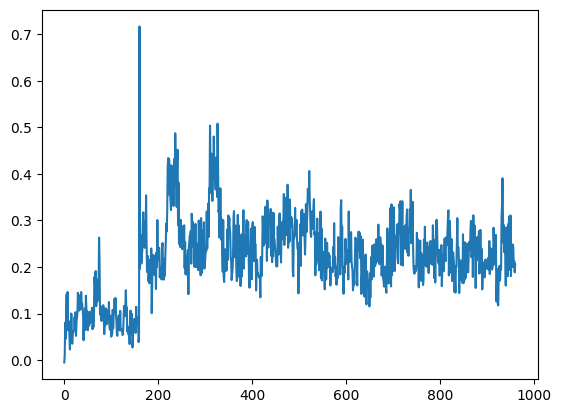

In [3]:
models = build_models(x_normal, config=CFG)
thresholds = compute_thresholds(models, x_normal, config=CFG)
reference_points = get_reference_points(x_normal)

print("Models:", models.keys())
print("Thresholds:")
for k, v in thresholds.items():
    print(k, v)
    
def build_all_explainers(model_name, reference, x_normal, models, method_labels):
    indicator_model = models[model_name]["indicator_model"]
    score_numpy = models[model_name]["score_numpy"]

    bg_size = min(SHAP_BG_SIZE, len(x_normal))
    background = x_normal[:bg_size]

    explainers = {}

    for method in method_labels:
        if method == "Gradient":
            explainers[method] = GradientAttribution(indicator_model)

        elif method == "IG":
            explainers[method] = IGAttribution(
                indicator_model,
                reference,
                steps=IG_STEPS
            )

        elif method == "SHAP":
            explainers[method] = SHAPAttribution(
                score_numpy,
                background,
                nsamples=SHAP_NSAMPLES,
                kmeans=None,
                batch_size=1
            )


        elif method == "VSF":
            explainers[method] = VSFAttribution(
                indicator_model,
                dt=CFG.vsf_step,               # 决定了动力学轨迹的光滑度
                max_steps=CFG.vsf_max_steps,   # 决定了寻路的彻底程度
                grad_tol=getattr(CFG, 'vsf_grad_tol', 1e-5), # 兼容您可能没有在CFG里定义这个变量的情况
                normalize=True
            )

        elif method == "DeepLIFT":
            explainers[method] = DeepLIFTAttribution(
                indicator_model,
                reference=reference
            )

    return explainers



# 2. 取出每个模型的打分函数（直接用这个预测）
t2_score_func = models["T²"]["score_numpy"]
svdd_score_func = models["SVDD"]["score_numpy"]
ae_score_func = models["AE"]["score_numpy"]

# 3. 直接传入数据 → 输出异常分数（越高越异常）
t2_scores = t2_score_func(x_outliers)      # T² 分数
svdd_scores = svdd_score_func(x_outliers)  # SVDD 分数
ae_scores = ae_score_func(x_outliers)      # AE 分数

plt.plot(svdd_scores)
plt.show()


In [4]:
model_names = ["T²", "SVDD", "AE"]
method_labels = ["Gradient", "IG", "SHAP", "VSF", "DeepLIFT"]

fault_start = 0
n_vis = 960

x_vis = x_outliers[fault_start:fault_start + n_vis]
# x_vis = x_outliers  # 使用全部测试集
print(x_vis.shape)

contrib_dict_all = {}

for model_name in model_names:
    print("\n" + "=" * 60)
    print("Processing:", model_name)
    print("=" * 60)

    reference = reference_points[model_name]

    explainers = build_all_explainers(
        model_name,
        reference,
        x_normal,
        models,
        method_labels
    )

    contrib_dict_all[model_name] = {}

    for method in method_labels:
        print("Computing:", model_name, method)
        unified = get_unified_output(explainers[method], x_vis)
        contrib_dict_all[model_name][method] = unified["raw_contrib"]

print("Attribution finished.")


(960, 52)

Processing: T²
Computing: T² Gradient
Computing: T² IG
Computing: T² SHAP
Computing: T² VSF
Computing: T² DeepLIFT


Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished



Processing: SVDD
Computing: SVDD Gradient
Computing: SVDD IG
Computing: SVDD SHAP
Computing: SVDD VSF
Computing: SVDD DeepLIFT


Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished



Processing: AE
Computing: AE Gradient
Computing: AE IG
Computing: AE SHAP
Computing: AE VSF
Computing: AE DeepLIFT
[WARN] DeepLIFT structural failure → fallback (multi-baseline DeepLIFT-like)
Attribution finished.


In [5]:
def check_known_fault_variables(
    contrib_dict_all,
    feature_names,
    true_fault_vars=(0, 1, 2),
    top_k=10
):
    summary = []

    for model_name, contrib_dict in contrib_dict_all.items():
        print("\n" + "=" * 70)
        print(f"Model: {model_name}")
        print("=" * 70)

        for method, contrib in contrib_dict.items():
            contrib = np.asarray(contrib, dtype=np.float32)

            abs_c = np.abs(contrib)
            ratio = abs_c / (abs_c.sum(axis=1, keepdims=True) + 1e-8)

            mean_ratio = ratio.mean(axis=0)
            order = np.argsort(-mean_ratio)

            top_vars = order[:top_k]

            hit_top3 = [v for v in true_fault_vars if v in order[:3]]
            hit_top5 = [v for v in true_fault_vars if v in order[:5]]

            print(f"\nMethod: {method}")
            print("Top variables:", [feature_names[i] for i in top_vars])
            print("Top scores:", [round(float(mean_ratio[i]), 4) for i in top_vars])
            print("True vars in Top-3:", [feature_names[i] for i in hit_top3])
            print("True vars in Top-5:", [feature_names[i] for i in hit_top5])

            summary.append({
                "Model": model_name,
                "Method": method,
                "Top1": feature_names[order[0]],
                "Top2": feature_names[order[1]],
                "Top3": feature_names[order[2]],
                "X1_rank": int(np.where(order == 0)[0][0]) + 1,
                "X2_rank": int(np.where(order == 1)[0][0]) + 1,
                "X3_rank": int(np.where(order == 2)[0][0]) + 1,
                "Top3_hit_count": len(hit_top3),
                "Top5_hit_count": len(hit_top5)
            })

    return pd.DataFrame(summary)


check_df = check_known_fault_variables(
    contrib_dict_all,
    feature_names,
    true_fault_vars=(0, 1, 2),
    top_k=10
)

check_df



Model: T²

Method: Gradient
Top variables: ['X51', 'X9', 'X21', 'X30', 'X46', 'X39', 'X22', 'X27', 'X31', 'X37']
Top scores: [0.1712, 0.0997, 0.0302, 0.0208, 0.0198, 0.0195, 0.0189, 0.0188, 0.0187, 0.0185]
True vars in Top-3: []
True vars in Top-5: []

Method: IG
Top variables: ['X51', 'X9', 'X39', 'X3', 'X27', 'X21', 'X24', 'X37', 'X30', 'X35']
Top scores: [0.5187, 0.0351, 0.0162, 0.0142, 0.0139, 0.0132, 0.0125, 0.0125, 0.0122, 0.0118]
True vars in Top-3: []
True vars in Top-5: ['X3']

Method: SHAP
Top variables: ['X51', 'X9', 'X33', 'X21', 'X39', 'X27', 'X3', 'X35', 'X30', 'X37']
Top scores: [0.5204, 0.036, 0.0187, 0.0153, 0.0153, 0.0127, 0.0125, 0.0117, 0.0115, 0.0115]
True vars in Top-3: []
True vars in Top-5: []

Method: VSF
Top variables: ['X51', 'X9', 'X39', 'X3', 'X27', 'X21', 'X24', 'X37', 'X30', 'X35']
Top scores: [0.5187, 0.0351, 0.0162, 0.0142, 0.0139, 0.0132, 0.0125, 0.0125, 0.0122, 0.0118]
True vars in Top-3: []
True vars in Top-5: ['X3']

Method: DeepLIFT
Top variables:

,Model,Method,Top1,Top2,Top3,X1_rank,X2_rank,X3_rank,Top3_hit_count,Top5_hit_count
0,T²,Gradient,X51,X9,X21,47,19,16,0,0
1,T²,IG,X51,X9,X39,43,16,4,0,1
2,T²,SHAP,X51,X9,X33,46,18,7,0,0
3,T²,VSF,X51,X9,X39,43,16,4,0,1
4,T²,DeepLIFT,X51,X9,X39,43,16,4,0,1
5,SVDD,Gradient,X51,X7,X13,47,25,6,0,0
6,SVDD,IG,X51,X39,X7,44,20,4,0,1
7,SVDD,SHAP,X51,X7,X13,47,30,7,0,0
8,SVDD,VSF,X51,X7,X13,43,19,5,0,1
9,SVDD,DeepLIFT,X51,X7,X13,43,19,5,0,1



[INFO] 高清图片已保存至: duoweiwei/duo_contribution_curves.png
[INFO] 矢量PDF已保存至: duoweiwei/duo_contribution_curves.pdf


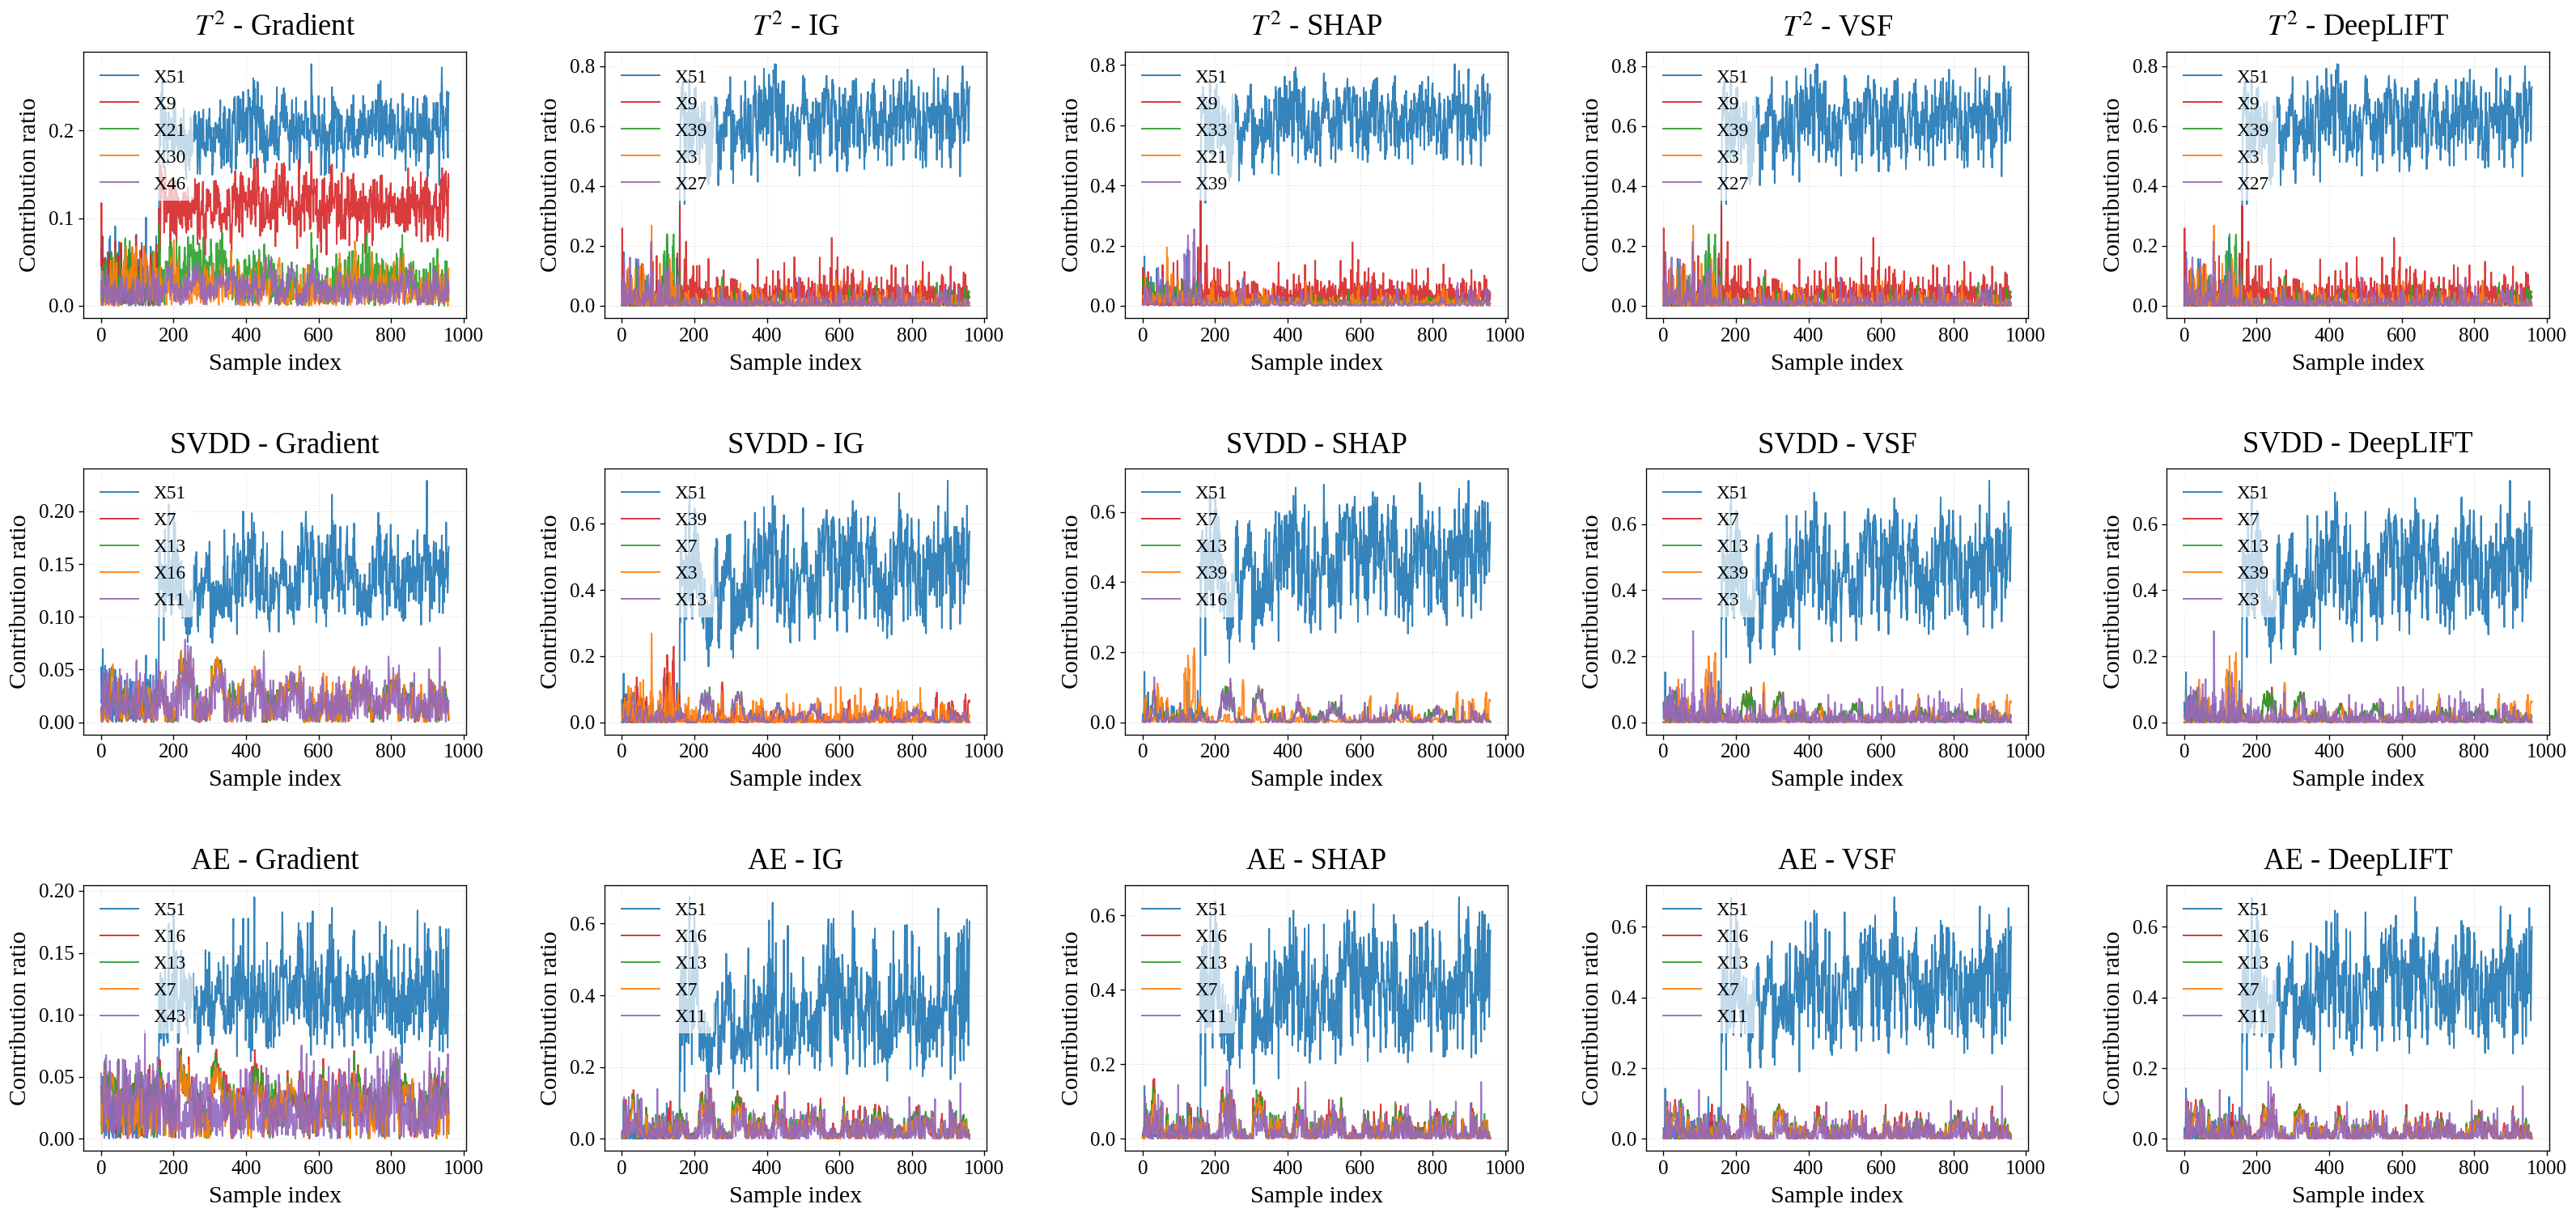

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 学术级绘图样式配置 (新罗马字体，不加粗)
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"], 
    "mathtext.fontset": "stix",  # 配合新罗马的数学公式字体引擎
    "axes.unicode_minus": False,
    "font.size": 14              # 新增：全局基础字号增大
})

def plot_known_fault_contribution_curves(
    contrib_dict_all,
    feature_names,
    top_k=5,
    save_dir="duoweiwei"
):
    """
    三行五列绘图：
    行 -> model（模型，如 T², SVDD, AE）
    列 -> method（方法，如 Gradient, IG, SHAP, VSF, DeepLIFT）
    """
    # 创建保存目录
    os.makedirs(save_dir, exist_ok=True)

    model_names = list(contrib_dict_all.keys())

    # 收集所有 method
    method_names = []
    for m in model_names:
        for method in contrib_dict_all[m].keys():
            if method not in method_names:
                method_names.append(method)

    n_rows = len(model_names)   # 行：模型 (3行)
    n_cols = len(method_names)  # 列：方法 (5列)
    
    # 动态获取全局 DPI
    fig_dpi = globals().get("FIG_DPI", 300)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.5 * n_cols, 4.5 * n_rows),
        dpi=fig_dpi
    )

    # 防止单行/单列问题
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    if n_cols == 1:
        axes = np.expand_dims(axes, axis=1)

    for i, model_name in enumerate(model_names):
        for j, method in enumerate(method_names):
            ax = axes[i, j]
            contrib_dict = contrib_dict_all[model_name]

            # 格式化模型名称
            formatted_model_name = model_name.replace("T²", r"$T^2$")

            # 没有该 method 时跳过
            if method not in contrib_dict:
                ax.set_title(f"{formatted_model_name}\n{method}\n(No data)", fontsize=18, fontweight='normal')
                ax.axis("off")
                continue

            contrib = np.asarray(
                contrib_dict[method],
                dtype=np.float32
            )

            abs_c = np.abs(contrib)

            ratio = abs_c / (
                abs_c.sum(axis=1, keepdims=True) + 1e-8
            )

            # Top-K
            mean_ratio = ratio.mean(axis=0)
            order = np.argsort(-mean_ratio)[:top_k]

            top_names = [feature_names[idx] for idx in order]

            # -------------------------
            # 绘制 TOP-K 曲线 (学术高级配色)
            # -------------------------
            colors = [
                '#1F77B4', '#D62728', '#2CA02C', '#FF7F0E', '#9467BD', 
                '#8C564B', '#E377C2', '#7F7F7F', '#BCBD22', '#17BECF',
            ]
            
            for idx, v in enumerate(order):
                ax.plot(
                    ratio[:, v],
                    linewidth=1.2, 
                    label=top_names[idx],
                    color=colors[idx % len(colors)],
                    alpha=0.9
                )

            # 【修改项 1】：子图标题字号增大 (16 -> 22)
            ax.set_title(
                f"{formatted_model_name} - {method}", 
                fontsize=22,
                fontweight='normal',
                pad=12
            )

            # 【修改项 2】：XY 轴标签字号增大 (14 -> 18)
            ax.set_xlabel("Sample index", fontsize=18, labelpad=6)
            ax.set_ylabel("Contribution ratio", fontsize=18, labelpad=6)

            ax.grid(
                True,
                linestyle=":",
                alpha=0.4,
                linewidth=0.8
            )

            # 【修改项 3】：图例字号增大 (10 -> 14)
            ax.legend(
                fontsize=14,
                loc="upper left", 
                frameon=True,
                edgecolor='none',
                facecolor='white',
                framealpha=0.7
            )
            
            # 【修改项 4】：坐标轴刻度数字字号增大 (11 -> 15)
            ax.tick_params(axis='both', which='major', labelsize=15)

    plt.tight_layout(pad=3.0)
    
    # 保存图像
    save_path = os.path.join(save_dir, "duo_contribution_curves.png")
    pdf_path = os.path.join(save_dir, "duo_contribution_curves.pdf")
    
    plt.savefig(save_path, dpi=fig_dpi, bbox_inches='tight')
    plt.savefig(pdf_path, format="pdf", bbox_inches='tight')
    
    print(f"\n[INFO] 高清图片已保存至: {save_path}")
    print(f"[INFO] 矢量PDF已保存至: {pdf_path}")

    plt.show()
    plt.close(fig)

# 调用
plot_known_fault_contribution_curves(
    contrib_dict_all=contrib_dict_all,
    feature_names=feature_names,
    top_k=5,
    save_dir="duoweiwei"
)

[INFO] 柱状图已保存至: duoweiwei/top_variable.png
[INFO] PDF已保存至: duoweiwei/top_variable.pdf


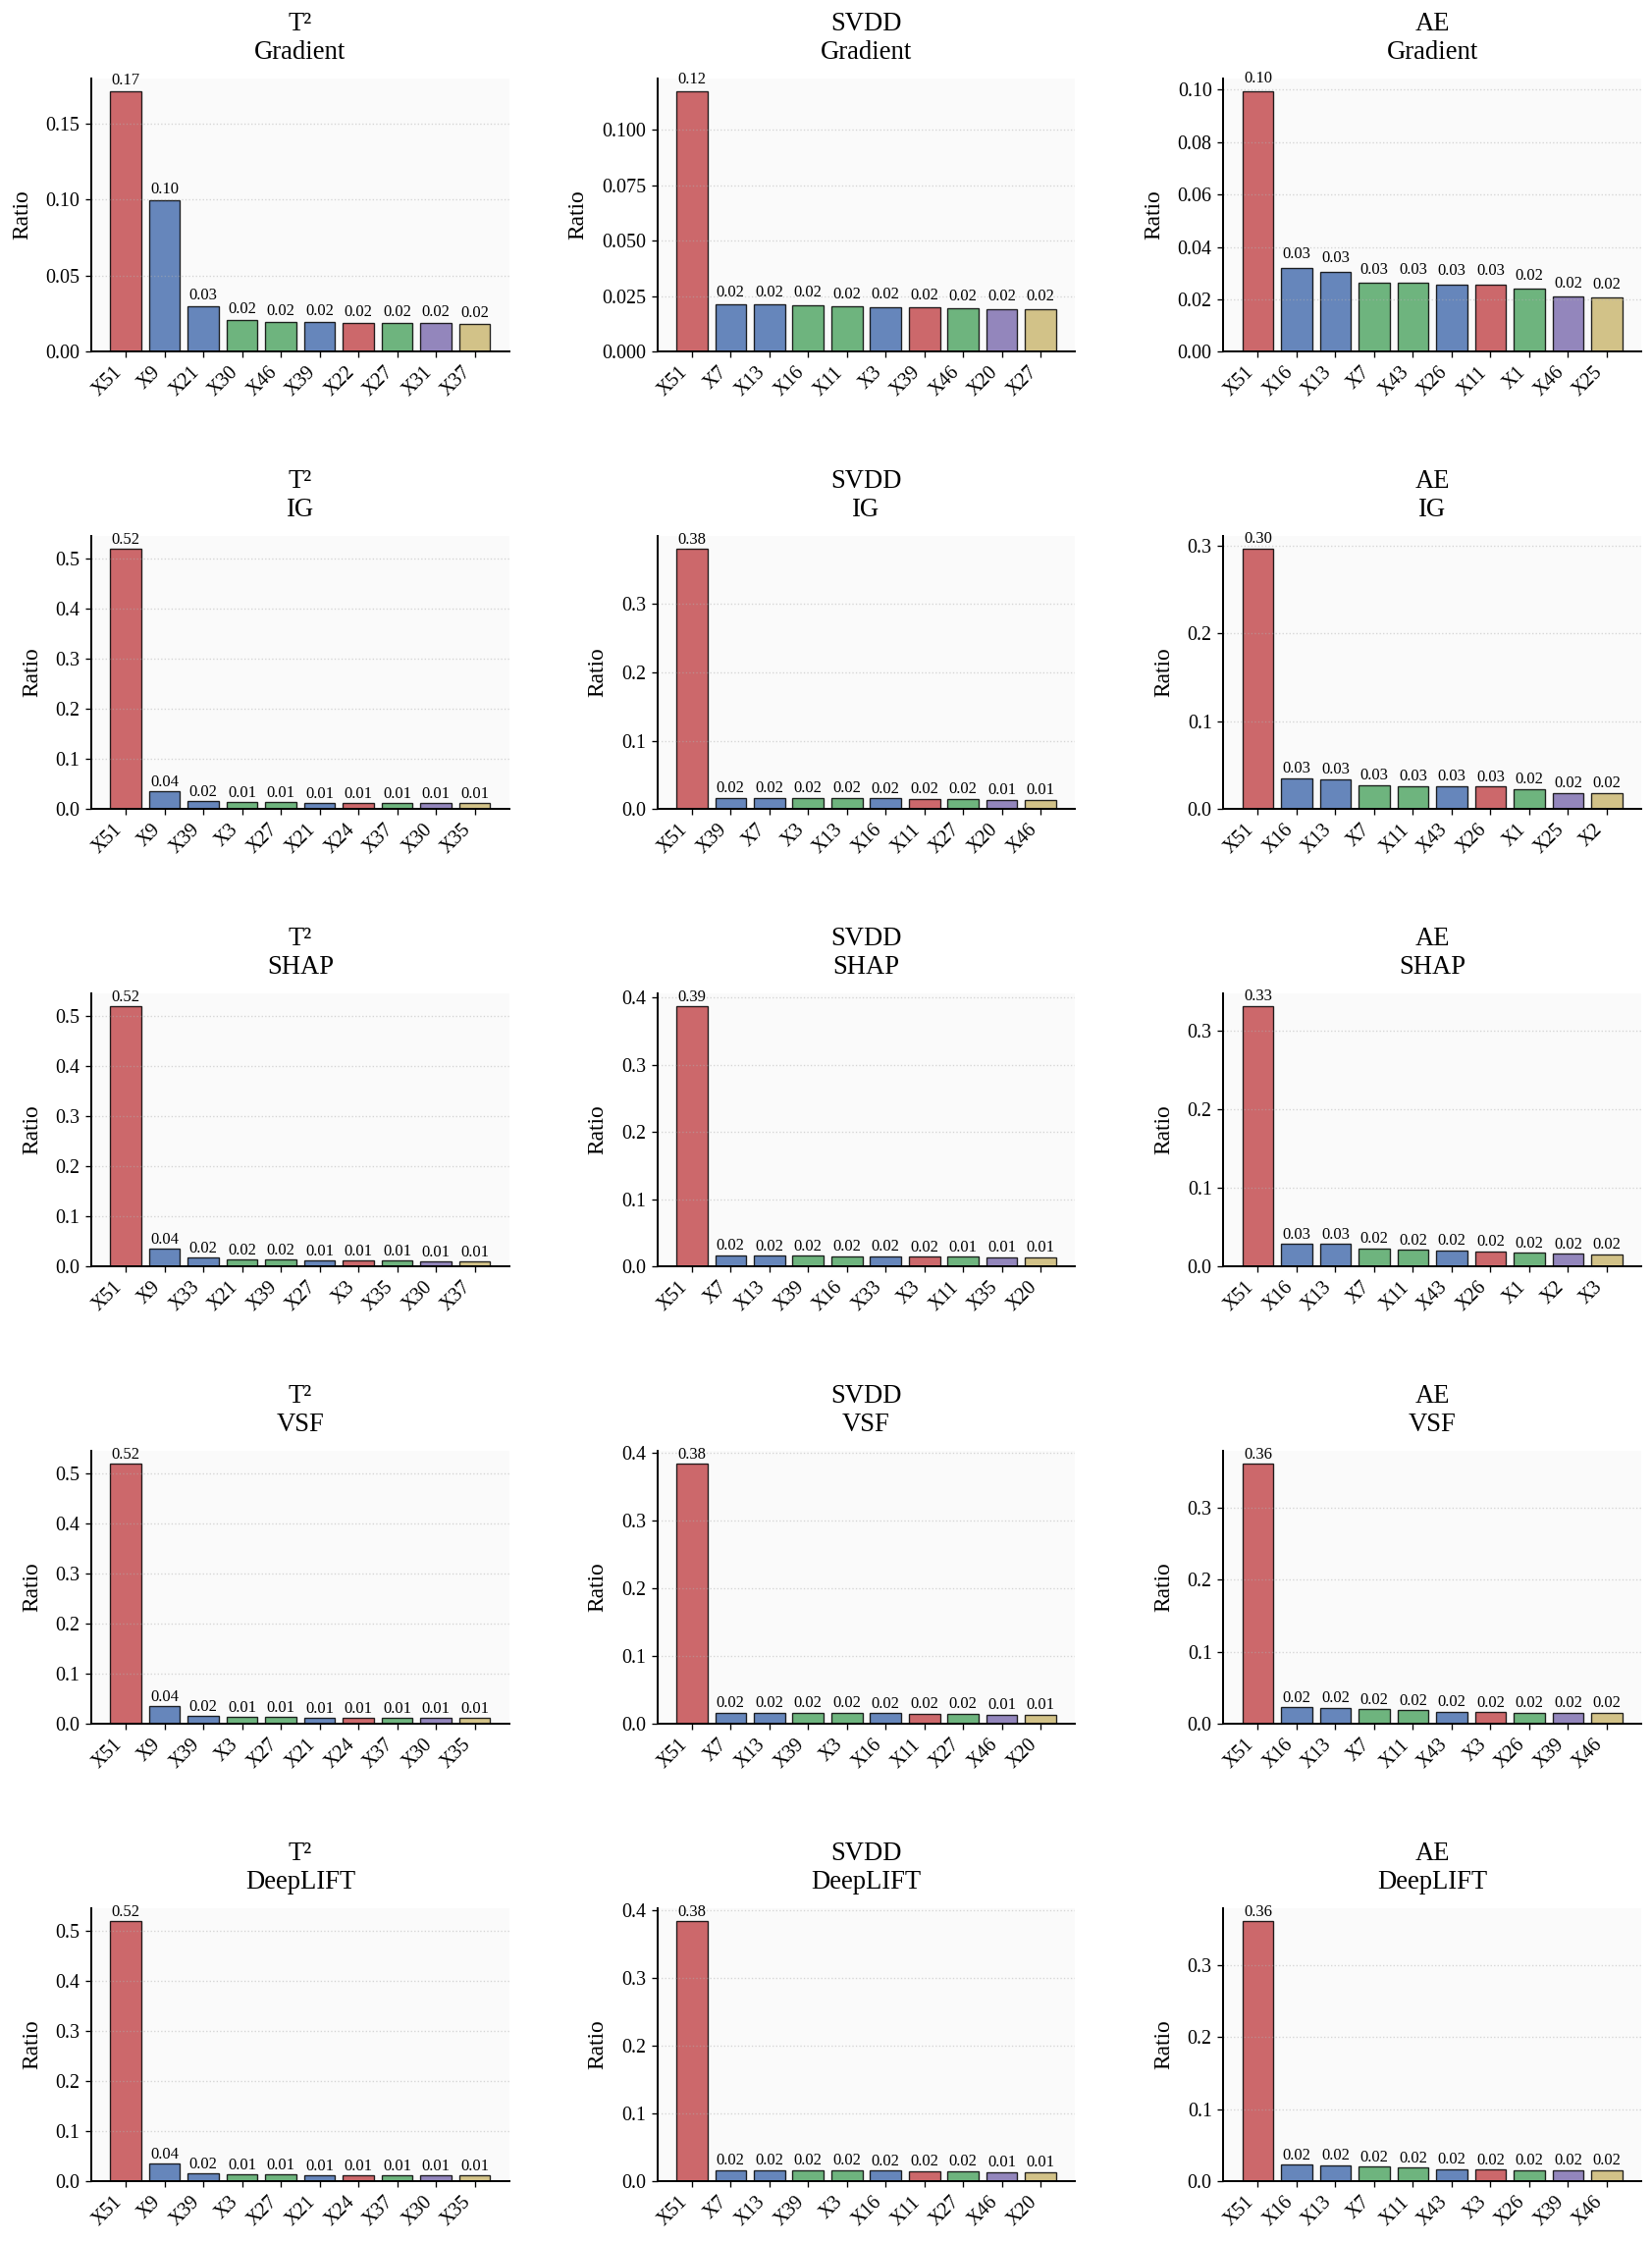


 ('T²', 'Gradient')
X51                  0.1712
X9                   0.0997
X21                  0.0302
X30                  0.0208
X46                  0.0198
X39                  0.0195
X22                  0.0189
X27                  0.0188
X31                  0.0187
X37                  0.0185

 ('SVDD', 'Gradient')
X51                  0.1172
X7                   0.0213
X13                  0.0212
X16                  0.0210
X11                  0.0204
X3                   0.0202
X39                  0.0200
X46                  0.0194
X20                  0.0194
X27                  0.0192

 ('AE', 'Gradient')
X51                  0.0993
X16                  0.0321
X13                  0.0305
X7                   0.0262
X43                  0.0262
X26                  0.0258
X11                  0.0257
X1                   0.0239
X46                  0.0209
X25                  0.0207

 ('T²', 'IG')
X51                  0.5187
X9                   0.0351
X39                  0.0

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

FIG_DPI = 120


def plot_top_variable_bar_grid(
    contrib_dict_all,
    feature_names,
    top_k=10,
    method_order=("Gradient", "IG", "SHAP", "VSF", "DeepLIFT"),
    save_dir="duoweiwei"
):
    # 创建保存目录
    os.makedirs(save_dir, exist_ok=True)
    
    model_names = list(contrib_dict_all.keys())

    n_rows = len(method_order)   # 行：方法
    n_cols = len(model_names)    # 列：模型

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        dpi=FIG_DPI
    )

    # 防止单行/单列问题
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    if n_cols == 1:
        axes = np.expand_dims(axes, axis=1)

    results = {}

    for row, method in enumerate(method_order):
        for col, model_name in enumerate(model_names):
            ax = axes[row, col]
            contrib_dict = contrib_dict_all[model_name]

            # 跳过不存在数据
            if method not in contrib_dict or contrib_dict[method] is None:
                ax.set_title(f"{model_name}-{method}\n(No data)", fontsize=14)
                ax.axis("off")
                continue

            contrib = np.asarray(contrib_dict[method], dtype=np.float32)

            abs_c = np.abs(contrib)
            row_sums = abs_c.sum(axis=1, keepdims=True)
            ratio = abs_c / (row_sums + 1e-8)
            mean_ratio = ratio.mean(axis=0)

            order = np.argsort(-mean_ratio)[:top_k]

            names = np.array(feature_names)[order]
            values = mean_ratio[order]

            results[(model_name, method)] = list(zip(names, values))

            # =========================
            # 配色方案（蓝红绿为主）
            # =========================
            base_palette = [
                "#4C72B0",  # 蓝
                "#C44E52",  # 红
                "#55A868",  # 绿
                "#8172B2",  # 紫
                "#CCB974",  # 土黄
                "#64B5CD",  # 青
                "#E17C05",  # 深橙
                "#937860",  # 棕
                "#DA8BC3",  # 粉
                "#8C8C8C"   # 灰
            ]

            colors = []
            for i in range(len(values)):
                if i == 0:
                    colors.append("#C44E52")   # 最重要的用红色
                elif i < 3:
                    colors.append("#4C72B0")   # 次重要的用蓝色
                elif i < 5:
                    colors.append("#55A868")   # 再次用绿色
                else:
                    colors.append(base_palette[(i - 5) % len(base_palette)])

            bars = ax.bar(
                names,
                values,
                color=colors,
                edgecolor="black",
                linewidth=0.8,
                alpha=0.85
            )

            # =========================
            # 数值标签
            # =========================
            for i, (bar, val) in enumerate(zip(bars, values)):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    val + 0.002,
                    f"{val:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=10
                )

            # =========================
            # 标题 & 样式
            # =========================
            ax.set_title(f"{model_name}\n{method}", fontsize=16, pad=12)

            ax.set_ylabel("Ratio", fontsize=14, labelpad=8)

            ax.set_xticks(range(len(names)))
            ax.set_xticklabels(names, rotation=45, ha="right", fontsize=12)

            # 刻度字体
            ax.tick_params(axis='y', labelsize=12)

            ax.grid(axis="y", linestyle=":", alpha=0.5, linewidth=0.8)

            # 去掉多余边框
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_linewidth(1.2)
            ax.spines["bottom"].set_linewidth(1.2)

            # 设置背景色
            ax.set_facecolor('#FAFAFA')

    # 设置整体背景
    fig.patch.set_facecolor('white')

    plt.tight_layout(pad=3.0)
    
    # 保存图像
    save_path = os.path.join(save_dir, "top_variable.png")
    pdf_path = os.path.join(save_dir, "top_variable.pdf")
    
    plt.savefig(save_path, dpi=FIG_DPI, bbox_inches='tight')
    plt.savefig(pdf_path, bbox_inches='tight')
    
    print(f"[INFO] 柱状图已保存至: {save_path}")
    print(f"[INFO] PDF已保存至: {pdf_path}")
    
    plt.show()
    plt.close(fig)

    return results


# =========================
# 调用
# =========================
results = plot_top_variable_bar_grid(
    contrib_dict_all=contrib_dict_all,
    feature_names=feature_names,
    top_k=10,
    method_order=("Gradient", "IG", "SHAP", "VSF", "DeepLIFT"),
    save_dir="duoweiwei"
)


# =========================
# 打印结果
# =========================
for k, v in results.items():
    print("\n", k)
    for name, score in v:
        print(f"{name:<20s} {score:.4f}")

图形已保存至：removal_test_plot.pdf


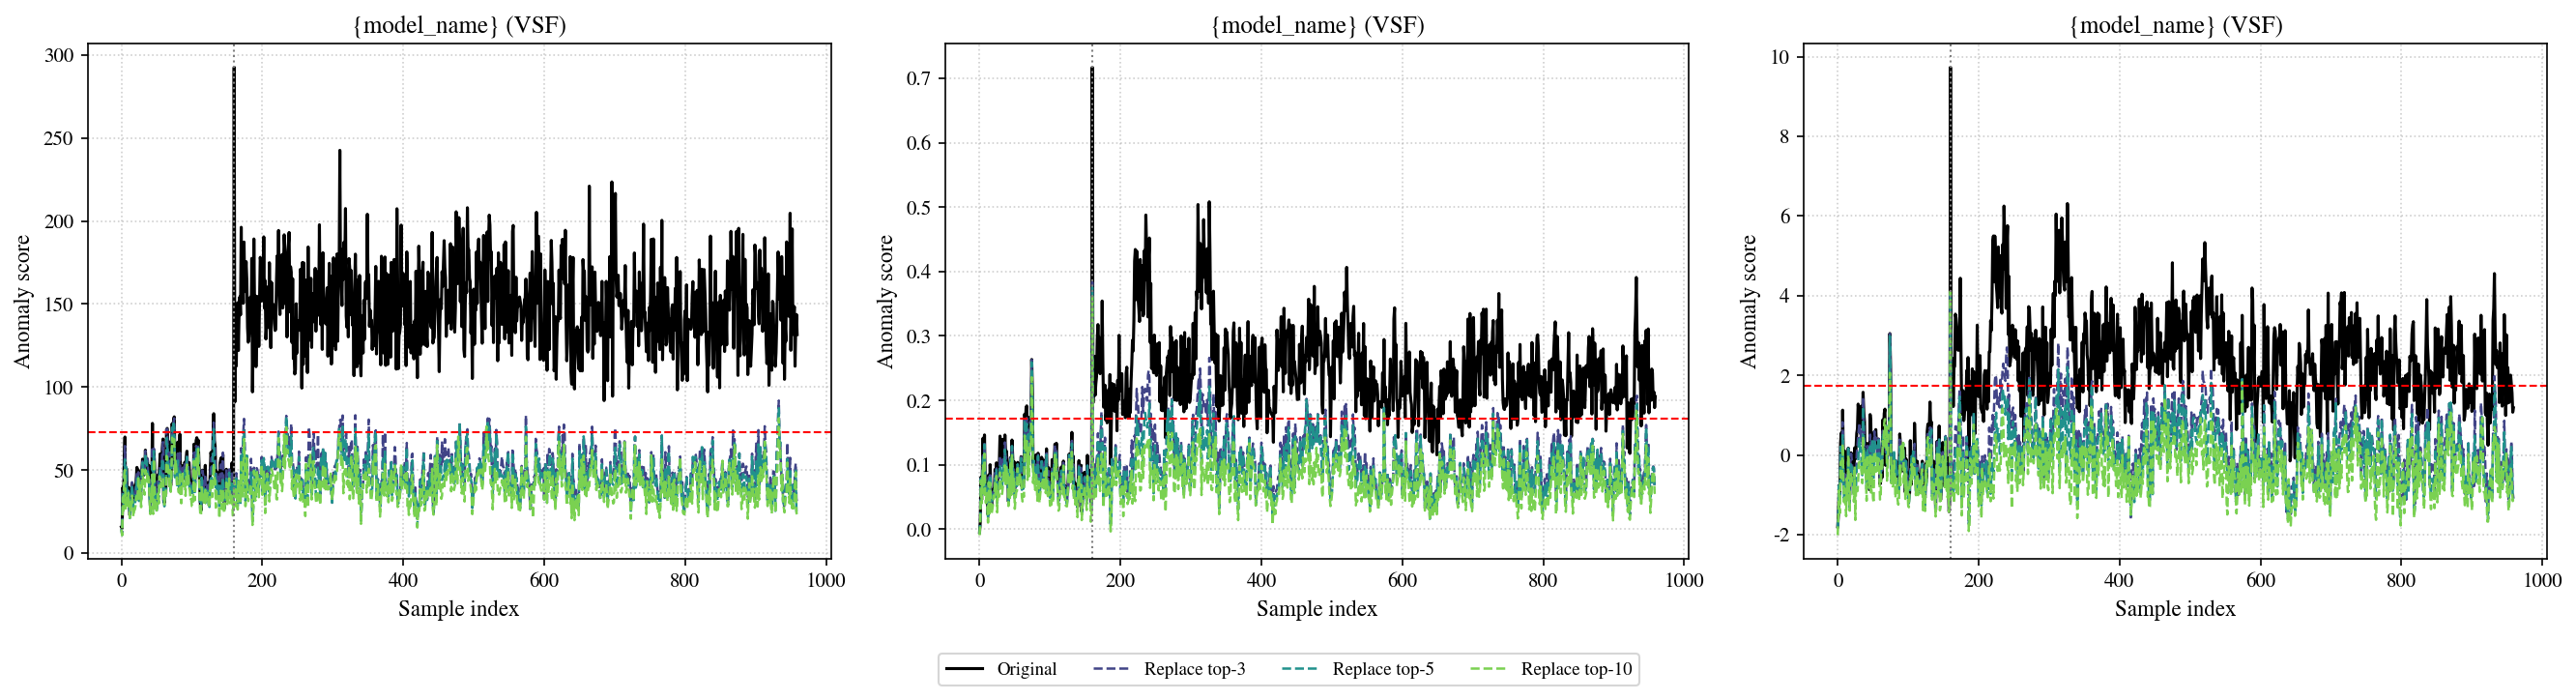

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import math

# =========================
# 设置学术风格参数
# =========================
# =========================
# 设置学术风格参数 (使用 STIX 替代 Times New Roman)
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"], # STIX 是 Matplotlib 自带的，无需安装，外观极像 Times
    "mathtext.fontset": "stix",    # 让公式字体也匹配
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150
})
def plot_removal_test_for_indicators(
    models, reference_points, x_test_scaled, threshold_dict,
    fault_start_idx=160, attribution_method="VSF",
    k_list=(3, 5, 10), figsize=(18, 5), save_path=None   # 新增 save_path 参数
):
    indicator_names = list(models.keys())
    nrows = math.ceil(len(indicator_names) / 3)
    
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(figsize[0], figsize[1] * nrows))
    axes_flat = axes.flatten()

    for idx, model_name in enumerate(indicator_names):
        ax = axes_flat[idx]
        score_func = models[model_name]["score_numpy"]
        threshold = threshold_dict[model_name]
        reference = reference_points[model_name]

        # 注意：此处依赖外部定义的 x_normal, build_all_explainers, get_unified_output
        # 请确保这些变量/函数在实际运行前已定义
        explainer = build_all_explainers(model_name, reference, x_normal, models, [attribution_method])[attribution_method]
        attrib_result = get_unified_output(explainer, x_test_scaled)
        contrib = attrib_result["abs_contrib"]
        order = np.argsort(-np.mean(contrib[fault_start_idx:], axis=0))

        ax.plot(score_func(x_test_scaled).ravel(), color="black", linewidth=1.5, label="Original")
        
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(k_list)))
        for i, k in enumerate(k_list):
            k = min(k, x_test_scaled.shape[1])
            x_removed = x_test_scaled.copy()
            x_removed[:, order[:k]] = reference[order[:k]]
            ax.plot(score_func(x_removed).ravel(), color=colors[i], linewidth=1.2, linestyle="--", label=f"Replace top-{k}")

        ax.axvline(fault_start_idx, color="gray", linestyle=":", linewidth=1)
        ax.axhline(threshold, color="red", linestyle="--", linewidth=1)
        
        ax.set_title(f"{{model_name}} ({attribution_method})")
        ax.set_xlabel("Sample index")
        ax.set_ylabel("Anomaly score")
        ax.grid(True, linestyle=":", alpha=0.6)

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=len(labels), frameon=True)

    for j in range(len(indicator_names), len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout(rect=[0, 0.08, 1, 1])

    # 保存为 PDF（如果指定了路径）
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"图形已保存至：{save_path}")
    else:
        plt.show()

# 调用示例：保存为 PDF
plot_removal_test_for_indicators(
    models=models,
    reference_points=reference_points,
    x_test_scaled=x_outliers,
    threshold_dict=thresholds,
    fault_start_idx=160,
    attribution_method="VSF",
    save_path="removal_test_plot.pdf"   # 指定保存路径
)

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import os

def format_p_value(p):
    """学术风格 P 值格式化：严格遵循 <0.05, <0.001 规范"""
    if pd.isna(p) or p is None: return "N/A"
    if p < 0.001: return "<0.001"
    if p < 0.05: return "<0.05"
    return f"{p:.3f}"

def generate_fer_tables(DATA_PATH, models, thresholds, reference_points, scaler, method_labels, x_normal):
    print(f"\n{'='*65}\n 开始构建统计分析表 (均值±标准差, 含 Kruskal-Wallis H 检验) \n{'='*65}")
    
    global_records = []
    
    # ==========================================
    # 1. 数据采集阶段
    # ==========================================
    for model_name in ["T²", "SVDD", "AE"]:
        score_func = models[model_name]["score_numpy"]
        explainers = build_all_explainers(model_name, reference_points[model_name], x_normal, models, method_labels)
        
        print(f"[数据采集] 正在处理监测模型: {model_name} ...")
        
        for f_idx in range(1, 22):
            file_path = os.path.join(DATA_PATH, f"d{f_idx:02d}_te.dat")
            if not os.path.exists(file_path): continue
                
            df_f = pd.read_csv(file_path, sep=r"\s+", header=None)
            x_test = scaler.transform(df_f.values).astype(np.float32)[160:]
            
            for method in method_labels:
                if method not in explainers or explainers[method] is None: continue
                try:
                    unified = get_unified_output(explainers[method], x_test)
                    fer = compute_fer_curve(score_func, x_test, thresholds[model_name], unified["raw_contrib"], reference_points[model_name])
                    global_records.append({
                        "Model": model_name, "Method": method,
                        "Top-3": fer[2]*100, "Top-5": fer[4]*100, "Top-10": fer[9]*100
                    })
                except Exception: continue

    # ==========================================
    # 2. 统计处理与检验阶段 (计算 均值、标准差、H、P)
    # ==========================================
    df = pd.DataFrame(global_records)
    metrics = ["Top-3", "Top-5", "Top-10"]
    
    results_combined = []

    for model in ["T²", "SVDD", "AE"]:
        for metric in metrics:
            subset = df[df['Model'] == model]
            
            # 提取参与对比的各方法得分，用于统计检验
            groups = [subset[subset['Method'] == m][metric].values for m in method_labels]
            valid_groups = [g for g in groups if len(g) > 0]
            
            # 执行 Kruskal-Wallis H 检验
            if len(valid_groups) >= 2:
                try:
                    h, p = stats.kruskal(*valid_groups)
                except ValueError:
                    h, p = 0.0, np.nan
            else:
                h, p = 0.0, np.nan
            
            # 建立合并行字典，用于存储 "均值±标准差" 以及 H 和 P
            row_combined = {"Model": model, "Metric": metric}
            
            for m in method_labels:
                m_data = subset[subset['Method'] == m][metric].values
                if len(m_data) > 0:
                    mean_val = np.mean(m_data)
                    std_val = np.std(m_data, ddof=1)
                    # 将均值和标准差合并为一个字符串，格式为 均值±标准差
                    row_combined[m] = f"{mean_val:.2f}±{std_val:.2f}"
                else:
                    row_combined[m] = "N/A"
            
            # 将 H 和 P 值追加到当前行字典的末尾
            row_combined["H"] = round(h, 2)
            row_combined["P"] = format_p_value(p)
                
            results_combined.append(row_combined)

    # ==========================================
    # 3. 最终排版整理
    # ==========================================
    table_combined = pd.DataFrame(results_combined).set_index(['Model', 'Metric'])
    
    # 将 H 和 P 列明确移动到表的最右侧对齐
    cols = [c for c in table_combined.columns if c not in ['H', 'P']] + ['H', 'P']
    table_combined = table_combined[cols]
    
    print("\n[完成] 均值±标准差表（右侧带 H、P 值）已生成。")
    return table_combined

# ==========================================
# 执行并导出
# ==========================================
table_combined = generate_fer_tables(
    DATA_PATH=DATA_PATH, 
    models=models, 
    thresholds=thresholds, 
    reference_points=reference_points, 
    scaler=scaler, 
    method_labels=method_labels,
    x_normal=x_normal
)

# 打印表格查看结构 (Jupyter Notebook 环境)
display(table_combined)

# 若后续需要导出为 LaTeX 插入论文，请取消以下注释：
# 注意：由于包含 ± 符号，导出时替换为 LaTeX 语法的 \pm，并设置 escape=False
# latex_str = table_combined.to_latex(caption="Statistical Results of FER with H-test.", label="tab:fer_stat", escape=False)
# print(latex_str.replace("±", r"$\pm$"))


 开始构建统计分析表 (均值±标准差, 含 Kruskal-Wallis H 检验) 
[数据采集] 正在处理监测模型: T² ...


Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will b

In [ ]:
# =========================================================================
# 【优化版】: 严格对齐论文公式，全自动遍历 21 个工业故障的 FER 统计
# =========================================================================
import os
import pandas as pd
import numpy as np

def compute_fer_curve(score_func, x_test, threshold, contrib, ref):

    x_test = np.asarray(x_test, dtype=np.float32)
    contrib = np.asarray(contrib, dtype=np.float32)
    ref = np.asarray(ref, dtype=np.float32).reshape(-1)
    
    n_features = x_test.shape[1]
    fer = []

    # 1. 识别故障样本集合 F (论文中的 S(xi) > h)
    original_scores = score_func(x_test).ravel()
    mask_fault = original_scores > threshold
    
    # 如果该模型完全没有检测出故障，直接返回全 0
    if np.sum(mask_fault) == 0:
        return np.zeros(n_features)

    # 2. 核心改进：计算绝对贡献均值，获取正确的排序 order
    contrib_fault = contrib[mask_fault]
    mean_abs = np.mean(np.abs(contrib_fault), axis=0)
    order = np.argsort(-mean_abs)

    # 3. 逐个移除 Top-k 变量，计算 FER
    for k in range(1, n_features + 1):
        x_mod = x_test.copy()
        top_idx = order[:k]
        x_mod[:, top_idx] = ref[top_idx] # 变量替换机制 xi_j^(k) = xref_j

        scores_fixed = score_func(x_mod).ravel()
        # 故障被消除的条件：原始是故障，替换后得分 <= 阈值
        eliminated = (scores_fixed <= threshold) & mask_fault
        
        # FER(k) = 成功消除的样本数 / 原始总故障样本数
        fer_k = np.sum(eliminated) / np.sum(mask_fault)
        fer.append(fer_k)

    return np.array(fer)

def generate_global_fer_benchmark_table(DATA_PATH, models, thresholds, reference_points, scaler, method_labels):
    print(f"\n{'='*30} 开始构建 21 种故障的全局 FER 性能表 {'='*30}")
    global_records = []
    
    for model_name in ["T²", "SVDD", "AE"]:
        print(f"\n[处理中] 监测模型: {model_name} ...")
        score_func = models[model_name]["score_numpy"]
        threshold = thresholds[model_name]
        ref = reference_points[model_name]
        
        explainers = build_all_explainers(model_name, ref, x_normal, models, method_labels)
        
        for f_idx in range(1, 22):
            file_name = f"d{f_idx:02d}_te.dat"
            file_path = os.path.join(DATA_PATH, file_name)
            
            if not os.path.exists(file_path):
                continue
                
            df_f = pd.read_csv(file_path, sep=r"\s+", header=None)
            x_test_f = scaler.transform(df_f.values).astype(np.float32)
            

            x_test_fault_only = x_test_f[160:]
            
            for method in method_labels:
                if method not in explainers or explainers[method] is None:
                    continue
                try:
                    unified = get_unified_output(explainers[method], x_test_fault_only)
                    contrib = unified["raw_contrib"]
                    
                    # 调用优化后的 FER 计算引擎
                    fer_curve = compute_fer_curve(
                        score_func=score_func, x_test=x_test_fault_only,
                        threshold=threshold, contrib=contrib, ref=ref
                    )
                    
                    fer_3  = fer_curve[2]  if len(fer_curve) >= 3  else 0.0
                    fer_5  = fer_curve[4]  if len(fer_curve) >= 5  else 0.0
                    fer_10 = fer_curve[9]  if len(fer_curve) >= 10 else 0.0
                    
                    global_records.append({
                        "Model": model_name,
                        "Fault": f"F{f_idx}",
                        "Method": method,
                        "Top-3": round(fer_3 * 100, 2),
                        "Top-5": round(fer_5 * 100, 2),
                        "Top-10": round(fer_10 * 100, 2)
                    })
                except Exception as e:
                    pass

    df = pd.DataFrame(global_records)
    
    # =========================================================
    # 数据透视：将表格重组为论文常用的纵横排版格式
    # 行 = Model + Fault， 列 = Method 对应的 Top-K
    # =========================================================
    pivot_df = df.pivot_table(
        index=["Model", "Fault"],
        columns=["Method"],
        values=["Top-3", "Top-5", "Top-10"],
        aggfunc='first'
    )
    
    # 调整列顺序，让它们按照 Top-3, Top-5, Top-10 聚集
    pivot_df = pivot_df.reorder_levels([0, 1], axis=1).sort_index(axis=1, level=0)
    
    # 保存透视表方便直接贴入 Word / Excel
    pivot_df.to_csv("tep_fer_pivot_table_for_paper.csv", encoding="utf_8_sig")
    print("\n[成功] 论文级 FER 基准统计表构建完毕！已导出至: tep_fer_pivot_table_for_paper.csv")
    
    return pivot_df

# 执行大表生成
fer_pivot_table = generate_global_fer_benchmark_table(
    DATA_PATH=DATA_PATH,
    models=models,
    thresholds=thresholds,
    reference_points=reference_points,
    scaler=scaler,
    method_labels=method_labels
)

# 预览表格（结构适合论文）
fer_pivot_table.head(20)

In [ ]:
# ==========================================
# 0. 补充缺失的核心计算引擎 (精准版 FER)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def compute_fer_curve(score_func, x_test, threshold, contrib, ref):
    """
    改进版 FER 计算：仅在被判定为故障的样本上计算特征排序与消除率
    """
    x_test = np.asarray(x_test, dtype=np.float32)
    contrib = np.asarray(contrib, dtype=np.float32)
    ref = np.asarray(ref, dtype=np.float32).reshape(-1)
    
    n_features = x_test.shape[1]
    fer = []

    original_scores = score_func(x_test).ravel()
    mask_fault = original_scores > threshold
    
    if np.sum(mask_fault) == 0:
        return np.zeros(n_features)

    # 仅取故障样本计算平均贡献
    contrib_fault = contrib[mask_fault]
    mean_abs = np.mean(np.abs(contrib_fault), axis=0)
    order = np.argsort(-mean_abs)

    for k in range(1, n_features + 1):
        x_mod = x_test.copy()
        top_idx = order[:k]
        x_mod[:, top_idx] = ref[top_idx]

        scores_fixed = score_func(x_mod).ravel()
        eliminated = (scores_fixed <= threshold) & mask_fault
        fer.append(np.sum(eliminated) / np.sum(mask_fault))

    return np.array(fer)

# ==========================================
# 1. 加载 Fault 11 数据并处理
# ==========================================
print("Loading Fault 11 (d11_te.dat)...")
df_fault_11 = pd.read_csv(os.path.join(DATA_PATH, "d11_te.dat"), sep=r"\s+", header=None)
x_outliers_raw_11 = df_fault_11.values
x_outliers_11 = scaler.transform(x_outliers_raw_11).astype(np.float32)

fault_start_11 = 0
n_vis_11 = 960
x_vis_11 = x_outliers_11[fault_start_11:fault_start_11 + n_vis_11]

# 重新计算 Fault 11 的归因字典
contrib_dict_all_11 = {}
for model_name in model_names:
    print(f"\nProcessing {model_name} for Fault 11...")
    reference = reference_points[model_name]
    explainers_11 = build_all_explainers(model_name, reference, x_normal, models, method_labels)
    contrib_dict_all_11[model_name] = {}
    
    for method in method_labels:
        if method in explainers_11 and explainers_11[method] is not None:
            unified = get_unified_output(explainers_11[method], x_vis_11)
            contrib_dict_all_11[model_name][method] = unified["raw_contrib"]

# Fault 11 的真实根因变量主要是 X9
true_fault_vars_11 = (8,) 


# ==========================================
# 2. 绘制归因比例曲线 (优化视觉突出 VSF)
# ==========================================
def plot_beautiful_contribution_curves(contrib_dict_all, feature_names, top_k=5):
    for model_name, contrib_dict in contrib_dict_all.items():
        for method, contrib in contrib_dict.items():
            if contrib is None:
                continue
                
            contrib = np.asarray(contrib, dtype=np.float32)
            abs_c = np.abs(contrib)
            ratio = abs_c / (abs_c.sum(axis=1, keepdims=True) + 1e-8)

            mean_ratio = ratio.mean(axis=0)
            order = np.argsort(-mean_ratio)[:top_k]
            top_names = [feature_names[i] for i in order]

            plt.figure(figsize=(8, 4.5), dpi=FIG_DPI)

            for idx, v in enumerate(order):
                plt.plot(ratio[:, v], linewidth=1.5, label=top_names[idx])

            plt.title(f"{model_name} - {method}: Top-{top_k} Contribution Ratio (Fault 11)")
            plt.xlabel("Sample index")
            plt.ylabel("Contribution ratio")
            plt.grid(True, linestyle=":", alpha=0.5)
            
            # 严格置于底部，防止遮挡
            plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=top_k)
            plt.tight_layout()
            plt.show()

plot_beautiful_contribution_curves(contrib_dict_all_11, feature_names, top_k=5)


# ==========================================
# 3. 绘制 FER 曲线对比 (视觉强化 VSF)
# ==========================================
def plot_fer_comparison(contrib_dict_all, models, thresholds, reference_points, x_vis):
    for model_name, contrib_dict in contrib_dict_all.items():
        score_func = models[model_name]["score_numpy"]
        threshold = thresholds[model_name]
        ref = reference_points[model_name]

        plt.figure(figsize=(8, 4.5), dpi=FIG_DPI)

        for method in method_labels:
            if method not in contrib_dict or contrib_dict[method] is None:
                continue

            fer = compute_fer_curve(
                score_func=score_func,
                x_test=x_vis,
                threshold=threshold,
                contrib=contrib_dict[method],
                ref=ref
            )

            # 视觉引导策略：VSF 红色加粗带标记，其他方法灰色虚线弱化
            if method == "VSF":
                color = "#E74C3C"  # 亮红色
                linewidth = 2.8
                alpha = 1.0
                linestyle = "-"
                marker = "o"
                zorder = 10 # 确保 VSF 画在最上层
            else:
                color = "#95A5A6"  # 灰色
                linewidth = 1.5
                alpha = 0.7
                linestyle = "--"
                marker = ""
                zorder = 5

            plt.plot(
                np.arange(1, len(fer) + 1), fer,
                marker=marker, markersize=5,
                linewidth=linewidth, alpha=alpha,
                color=color, linestyle=linestyle,
                label=method, zorder=zorder
            )

        plt.title(f"{model_name}: FER Curve Comparison (Fault 11)")
        plt.xlabel("Top-k removed variables")
        plt.ylabel("FER (Feature Erasure Rate)")
        plt.ylim(-0.03, 1.05)
        
        # 只显示前 20 个变量的 x 轴，让初期曲线对比更明显
        plt.xlim(0, 20) 
        plt.grid(True, linestyle=":", alpha=0.5)
        
        # 严格置于底部，防止遮挡
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
        plt.tight_layout()
        plt.show()

plot_fer_comparison(contrib_dict_all_11, models, thresholds, reference_points, x_vis_11)

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 0. 强制更新 VSF 超参数 (极其关键)
# ==========================================
# 缩小步长，增加步数，逼迫 VSF 走非线性积分路径
CFG.vsf_step = 0.02
CFG.vsf_max_steps = 150
CFG.vsf_grad_tol = 1e-5

print("="*60)
print(f"当前 VSF 参数: step={CFG.vsf_step}, max_steps={CFG.vsf_max_steps}")
print("="*60)

# ==========================================
# 1. 核心计算引擎 (严谨版 FER)
# ==========================================
def compute_fer_curve_strict(score_func, x_test, threshold, contrib, ref):
    x_test = np.asarray(x_test, dtype=np.float32)
    contrib = np.asarray(contrib, dtype=np.float32)
    ref = np.asarray(ref, dtype=np.float32).reshape(-1)
    
    n_features = x_test.shape[1]
    fer = []

    original_scores = score_func(x_test).ravel()
    mask_fault = original_scores > threshold
    
    if np.sum(mask_fault) == 0:
        return np.zeros(n_features)

    contrib_fault = contrib[mask_fault]
    mean_abs = np.mean(np.abs(contrib_fault), axis=0)
    order = np.argsort(-mean_abs)

    for k in range(1, n_features + 1):
        x_mod = x_test.copy()
        top_idx = order[:k]
        x_mod[:, top_idx] = ref[top_idx]
        scores_fixed = score_func(x_mod).ravel()
        eliminated = (scores_fixed <= threshold) & mask_fault
        fer.append(np.sum(eliminated) / np.sum(mask_fault))

    return np.array(fer)

# ==========================================
# 2. 从头加载 Fault 14 数据
# ==========================================
print("\nLoading Fault 14 (d14_te.dat)...")
df_fault_14 = pd.read_csv(os.path.join(DATA_PATH, "d14_te.dat"), sep=r"\s+", header=None)
x_outliers_raw_14 = df_fault_14.values
x_outliers_14 = scaler.transform(x_outliers_raw_14).astype(np.float32)

fault_start_14 = 0
n_vis_14 = 960
x_vis_14 = x_outliers_14[fault_start_14:fault_start_14 + n_vis_14]

# ==========================================
# 3. 重新计算归因结果字典
# ==========================================
contrib_dict_all_14 = {}
for model_name in model_names:
    print(f"Processing {model_name} for Fault 14...")
    reference = reference_points[model_name]
    
    # 构建解释器 (此时传入的 CFG 已经是修改过步长的了)
    explainers_14 = build_all_explainers(model_name, reference, x_normal, models, method_labels)
    contrib_dict_all_14[model_name] = {}
    
    for method in method_labels:
        if method in explainers_14 and explainers_14[method] is not None:
            unified = get_unified_output(explainers_14[method], x_vis_14)
            contrib_dict_all_14[model_name][method] = unified["raw_contrib"]

print("\n[Data Ready] Fault 14 的归因字典已成功生成！")

# ==========================================
# 4. 直接绘制 1v1 对比矩阵图
# ==========================================
def plot_vsf_pairwise_comparison(contrib_dict_all, models, thresholds, reference_points, x_vis):
    baselines = ["Gradient", "IG", "SHAP", "DeepLIFT"]
    
    for model_name, contrib_dict in contrib_dict_all.items():
        print(f"\nGenerating 1v1 Pairwise Comparison for {model_name}...")
        
        score_func = models[model_name]["score_numpy"]
        threshold = thresholds[model_name]
        ref = reference_points[model_name]

        if "VSF" not in contrib_dict or contrib_dict["VSF"] is None:
            print(f"VSF not found in {model_name}, skipping.")
            continue
            
        fer_vsf = compute_fer_curve_strict(
            score_func=score_func, x_test=x_vis, threshold=threshold, 
            contrib=contrib_dict["VSF"], ref=ref
        )

        fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=120)
        fig.suptitle(f"{model_name}: VSF vs. Baselines (FER Curve on Fault 14)", fontsize=14, y=0.95)
        
        axes = axes.flatten()

        for idx, baseline in enumerate(baselines):
            ax = axes[idx]
            
            # 画 VSF
            ax.plot(
                np.arange(1, len(fer_vsf) + 1), fer_vsf,
                color="#e74c3c", marker="o", markersize=4,
                linewidth=2.8, zorder=10, label="VSF (Ours)"
            )
            
            # 画 基线
            if baseline in contrib_dict and contrib_dict[baseline] is not None:
                fer_baseline = compute_fer_curve_strict(
                    score_func=score_func, x_test=x_vis, threshold=threshold, 
                    contrib=contrib_dict[baseline], ref=ref
                )
                ax.plot(
                    np.arange(1, len(fer_baseline) + 1), fer_baseline,
                    color="#95a5a6", linestyle="--", marker="", 
                    linewidth=1.5, alpha=0.8, zorder=5, label=baseline
                )
            
            ax.set_title(f"VSF vs. {baseline}")
            ax.set_xlabel("Top-k removed variables")
            ax.set_ylabel("FER")
            ax.set_ylim(-0.05, 1.05)
            ax.set_xlim(0, 20)
            ax.grid(True, linestyle=":", alpha=0.5)
            ax.legend(loc='lower right', fontsize=10)

        plt.subplots_adjust(hspace=0.4, wspace=0.2)
        plt.show()

# 执行绘图
plot_vsf_pairwise_comparison(
    contrib_dict_all=contrib_dict_all_14, 
    models=models, 
    thresholds=thresholds, 
    reference_points=reference_points, 
    x_vis=x_vis_14
)

In [ ]:
# ==========================================
# 0. 补充缺失的核心计算引擎 (精准版 FER)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def compute_fer_curve(score_func, x_test, threshold, contrib, ref):
    """
    改进版 FER 计算：仅在被判定为故障的样本上计算特征排序与消除率
    """
    x_test = np.asarray(x_test, dtype=np.float32)
    contrib = np.asarray(contrib, dtype=np.float32)
    ref = np.asarray(ref, dtype=np.float32).reshape(-1)
    
    n_features = x_test.shape[1]
    fer = []

    original_scores = score_func(x_test).ravel()
    mask_fault = original_scores > threshold
    
    if np.sum(mask_fault) == 0:
        return np.zeros(n_features)

    # 仅取故障样本计算平均贡献
    contrib_fault = contrib[mask_fault]
    mean_abs = np.mean(np.abs(contrib_fault), axis=0)
    order = np.argsort(-mean_abs)

    for k in range(1, n_features + 1):
        x_mod = x_test.copy()
        top_idx = order[:k]
        x_mod[:, top_idx] = ref[top_idx]

        scores_fixed = score_func(x_mod).ravel()
        eliminated = (scores_fixed <= threshold) & mask_fault
        fer.append(np.sum(eliminated) / np.sum(mask_fault))

    return np.array(fer)

# ==========================================
# 1. 加载 Fault 11 数据并处理
# ==========================================
print("Loading Fault 11 (d11_te.dat)...")
df_fault_11 = pd.read_csv(os.path.join(DATA_PATH, "d11_te.dat"), sep=r"\s+", header=None)
x_outliers_raw_11 = df_fault_11.values
x_outliers_11 = scaler.transform(x_outliers_raw_11).astype(np.float32)

fault_start_11 = 0
n_vis_11 = 960
x_vis_11 = x_outliers_11[fault_start_11:fault_start_11 + n_vis_11]

# 重新计算 Fault 11 的归因字典
contrib_dict_all_11 = {}
for model_name in model_names:
    print(f"\nProcessing {model_name} for Fault 11...")
    reference = reference_points[model_name]
    explainers_11 = build_all_explainers(model_name, reference, x_normal, models, method_labels)
    contrib_dict_all_11[model_name] = {}
    
    for method in method_labels:
        if method in explainers_11 and explainers_11[method] is not None:
            unified = get_unified_output(explainers_11[method], x_vis_11)
            contrib_dict_all_11[model_name][method] = unified["raw_contrib"]

# Fault 11 的真实根因变量主要是 X9
true_fault_vars_11 = (8,) 


# ==========================================
# 2. 绘制归因比例曲线 (优化视觉突出 VSF)
# ==========================================
def plot_beautiful_contribution_curves(contrib_dict_all, feature_names, top_k=5):
    for model_name, contrib_dict in contrib_dict_all.items():
        for method, contrib in contrib_dict.items():
            if contrib is None:
                continue
                
            contrib = np.asarray(contrib, dtype=np.float32)
            abs_c = np.abs(contrib)
            ratio = abs_c / (abs_c.sum(axis=1, keepdims=True) + 1e-8)

            mean_ratio = ratio.mean(axis=0)
            order = np.argsort(-mean_ratio)[:top_k]
            top_names = [feature_names[i] for i in order]

            plt.figure(figsize=(8, 4.5), dpi=FIG_DPI)

            for idx, v in enumerate(order):
                plt.plot(ratio[:, v], linewidth=1.5, label=top_names[idx])

            plt.title(f"{model_name} - {method}: Top-{top_k} Contribution Ratio (Fault 11)")
            plt.xlabel("Sample index")
            plt.ylabel("Contribution ratio")
            plt.grid(True, linestyle=":", alpha=0.5)
            
            # 严格置于底部，防止遮挡
            plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=top_k)
            plt.tight_layout()
            plt.show()

plot_beautiful_contribution_curves(contrib_dict_all_11, feature_names, top_k=5)


# ==========================================
# 3. 绘制 FER 曲线对比 (视觉强化 VSF)
# ==========================================
def plot_fer_comparison(contrib_dict_all, models, thresholds, reference_points, x_vis):
    for model_name, contrib_dict in contrib_dict_all.items():
        score_func = models[model_name]["score_numpy"]
        threshold = thresholds[model_name]
        ref = reference_points[model_name]

        plt.figure(figsize=(8, 4.5), dpi=FIG_DPI)

        for method in method_labels:
            if method not in contrib_dict or contrib_dict[method] is None:
                continue

            fer = compute_fer_curve(
                score_func=score_func,
                x_test=x_vis,
                threshold=threshold,
                contrib=contrib_dict[method],
                ref=ref
            )

            # 视觉引导策略：VSF 红色加粗带标记，其他方法灰色虚线弱化
            if method == "VSF":
                color = "#E74C3C"  # 亮红色
                linewidth = 2.8
                alpha = 1.0
                linestyle = "-"
                marker = "o"
                zorder = 10 # 确保 VSF 画在最上层
            else:
                color = "#95A5A6"  # 灰色
                linewidth = 1.5
                alpha = 0.7
                linestyle = "--"
                marker = ""
                zorder = 5

            plt.plot(
                np.arange(1, len(fer) + 1), fer,
                marker=marker, markersize=5,
                linewidth=linewidth, alpha=alpha,
                color=color, linestyle=linestyle,
                label=method, zorder=zorder
            )

        plt.title(f"{model_name}: FER Curve Comparison (Fault 11)")
        plt.xlabel("Top-k removed variables")
        plt.ylabel("FER (Feature Erasure Rate)")
        plt.ylim(-0.03, 1.05)
        
        # 只显示前 20 个变量的 x 轴，让初期曲线对比更明显
        plt.xlim(0, 20) 
        plt.grid(True, linestyle=":", alpha=0.5)
        
        # 严格置于底部，防止遮挡
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
        plt.tight_layout()
        plt.show()

plot_fer_comparison(contrib_dict_all_11, models, thresholds, reference_points, x_vis_11)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. 核心定量指标计算函数 (AUC-FER & 稳定性)
# ==========================================
def compute_auc_fer(fer_curve):
    """
    计算 FER 曲线下面积 (AUC-FER)。
    AUC 越接近 1，说明该方法用越少的变量就消除了故障，性能越好。
    """
    # 采用梯形积分法，并进行归一化
    auc = np.trapz(fer_curve) / (len(fer_curve) - 1)
    return auc

def compute_temporal_stability(contrib_matrix, fault_start_idx=160, true_var_idx=8):
    """
    计算真实故障变量在故障发生后的贡献度方差 (波动率)。
    方差越小，说明归因越稳定，没有梯度白噪声。
    """
    contrib = np.asarray(contrib_matrix, dtype=np.float32)
    abs_c = np.abs(contrib)
    ratio = abs_c / (abs_c.sum(axis=1, keepdims=True) + 1e-8)
    
    # 提取真实故障变量在故障阶段的贡献比例
    fault_ratio = ratio[fault_start_idx:, true_var_idx]
    
    # 计算标准差 (衡量波动幅度)
    std_dev = np.std(fault_ratio)
    mean_val = np.mean(fault_ratio)
    
    return mean_val, std_dev, fault_ratio

# ==========================================
# 1. 论文杀手图 1：带 AUC 指标的强化版 FER 曲线
# ==========================================
def plot_enhanced_fer_with_auc(contrib_dict_all, models, thresholds, reference_points, x_vis):
    """
    强化视觉对比，并在图例中直接标出 AUC 分数。
    """
    for model_name, contrib_dict in contrib_dict_all.items():
        score_func = models[model_name]["score_numpy"]
        threshold = thresholds[model_name]
        ref = reference_points[model_name]

        fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
        
        auc_records = {}

        for method in method_labels:
            if method not in contrib_dict or contrib_dict[method] is None:
                continue

            fer = compute_fer_curve(
                score_func=score_func, x_test=x_vis, threshold=threshold, 
                contrib=contrib_dict[method], ref=ref
            )
            
            # 计算 AUC
            auc_score = compute_auc_fer(fer)
            auc_records[method] = auc_score

            # 视觉心机排版：VSF 绝对高亮，其余方法灰度化
            if method == "VSF":
                color = "#E74C3C"  # 醒目红
                linewidth = 3.0
                alpha = 1.0
                marker = "o"
                zorder = 10
            else:
                color = "#95A5A6"  # 黯淡灰
                linewidth = 1.5
                alpha = 0.6
                marker = ""
                zorder = 5

            ax.plot(
                np.arange(1, len(fer) + 1), fer,
                marker=marker, markersize=5,
                linewidth=linewidth, alpha=alpha,
                color=color, zorder=zorder,
                label=f"{method} (AUC: {auc_score:.3f})"
            )

        ax.set_title(f"{model_name}: FER Curve & AUC Comparison (Fault 11)", fontsize=14)
        ax.set_xlabel("Top-k removed variables", fontsize=12)
        ax.set_ylabel("FER (Feature Erasure Rate)", fontsize=12)
        ax.set_ylim(-0.03, 1.05)
        ax.set_xlim(0, 15) # 只展示前15个变量，放大早期的差距
        ax.grid(True, linestyle=":", alpha=0.5)
        
        # 将图例严格放置在底部，横向展开，绝不遮挡数据曲线
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=10)
        
        plt.tight_layout()
        plt.show()

# ==========================================
# 2. 论文杀手图 2：真实故障变量追踪与稳定性分析
# ==========================================
def plot_root_cause_tracking(contrib_dict_all, true_var_idx=8, true_var_name="X9"):
    """
    专门针对真正的故障变量，画出它在各个方法下的贡献度随时间的变化。
    用以暴击 Gradient 和 IG 的“高频抖动”缺陷。
    """
    for model_name, contrib_dict in contrib_dict_all.items():
        if "VSF" not in contrib_dict or contrib_dict["VSF"] is None:
            continue
            
        fig, ax = plt.subplots(figsize=(10, 4.5), dpi=120)
        
        print(f"\n[{model_name}] 稳定性指标定量评估 (真实故障变量 {true_var_name}):")
        
        for method in method_labels:
            if method not in contrib_dict or contrib_dict[method] is None:
                continue
                
            mean_val, std_dev, fault_ratio = compute_temporal_stability(
                contrib_dict[method], fault_start_idx=160, true_var_idx=true_var_idx
            )
            
            print(f" - {method:<10}: 平均贡献度 = {mean_val:.3f}, 波动幅度(Std) = {std_dev:.3f}")

            # 同样的心机排版
            if method == "VSF":
                color = "#2980B9"  # 这里用深蓝色显得更加稳定专业
                linewidth = 2.5
                alpha = 1.0
                zorder = 10
            else:
                color = "#BDC3C7"  # 浅灰
                linewidth = 1.0
                alpha = 0.5
                zorder = 5

            # 绘制 160 步（故障发生后）的曲线
            time_steps = np.arange(160, 160 + len(fault_ratio))
            ax.plot(
                time_steps, fault_ratio,
                linewidth=linewidth, alpha=alpha,
                color=color, zorder=zorder,
                label=f"{method} (Std: {std_dev:.3f})"
            )

        ax.set_title(f"{model_name}: Contribution Tracking of True Root Cause ({true_var_name})", fontsize=14)
        ax.set_xlabel("Sample index (Post-fault)", fontsize=12)
        ax.set_ylabel(f"{true_var_name} Contribution Ratio", fontsize=12)
        ax.grid(True, linestyle=":", alpha=0.5)
        
        # 将图例严格放置在底部，横向展开，绝不遮挡数据曲线
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=5, fontsize=10)
        
        plt.tight_layout()
        plt.show()

# ==========================================
# 3. 运行！生成结果
# ==========================================
# 前提：这里假设您的 contrib_dict_all_11 已经在上一个代码块中计算好了
print("="*60)
print("开始生成高级对比视图...")
print("="*60)

plot_enhanced_fer_with_auc(contrib_dict_all_11, models, thresholds, reference_points, x_vis_11)
plot_root_cause_tracking(contrib_dict_all_11, true_var_idx=8, true_var_name="X9")

In [ ]:
import numpy as np
import pandas as pd
from scipy import integrate

# ==========================================
# 核心指标计算引擎
# ==========================================
def compute_fer_curve_strict(score_func, x_test, threshold, contrib, ref):
    """严格版 FER 计算：只关注真实故障样本"""
    x_test = np.asarray(x_test, dtype=np.float32)
    contrib = np.asarray(contrib, dtype=np.float32)
    ref = np.asarray(ref, dtype=np.float32).reshape(-1)
    
    n_features = x_test.shape[1]
    fer = []

    original_scores = score_func(x_test).ravel()
    mask_fault = original_scores > threshold
    
    if np.sum(mask_fault) == 0:
        return np.zeros(n_features)

    contrib_fault = contrib[mask_fault]
    mean_abs = np.mean(np.abs(contrib_fault), axis=0)
    order = np.argsort(-mean_abs)

    for k in range(1, n_features + 1):
        x_mod = x_test.copy()
        top_idx = order[:k]
        x_mod[:, top_idx] = ref[top_idx]
        scores_fixed = score_func(x_mod).ravel()
        eliminated = (scores_fixed <= threshold) & mask_fault
        fer.append(np.sum(eliminated) / np.sum(mask_fault))

    return np.array(fer)

def generate_vsf_advantage_report(contrib_dict_all, models, thresholds, reference_points, x_vis, fault_start=160, true_var_idx=(8,)):
    """
    一键生成多维度归因评估报告 (输出 Pandas DataFrame)
    包含: Top-1/2/3 FER, AUC-FER, 时间波动率(Std), 归因信噪比(SNR)
    """
    print("="*70)
    print(" 正在计算多维度评估指标矩阵 (Quantitative Evaluation Matrix)...")
    print("="*70)
    
    records = []
    
    for model_name, contrib_dict in contrib_dict_all.items():
        score_func = models[model_name]["score_numpy"]
        threshold = thresholds[model_name]
        ref = reference_points[model_name]

        for method in method_labels:
            if method not in contrib_dict or contrib_dict[method] is None:
                continue
                
            contrib = np.asarray(contrib_dict[method], dtype=np.float32)
            
            # --- 维度 1 & 2: 早期消除率与 AUC-FER ---
            fer = compute_fer_curve_strict(score_func, x_vis, threshold, contrib, ref)
            auc_fer = np.trapz(fer) / (len(fer) - 1)
            
            # --- 维度 3: 时间抗噪稳定性 (真实变量的方差) ---
            # 计算归一化贡献度
            abs_c = np.abs(contrib)
            ratio = abs_c / (abs_c.sum(axis=1, keepdims=True) + 1e-8)
            
            # 提取故障发生后的阶段
            fault_ratio = ratio[fault_start:]
            
            # 如果有多个真实故障变量，取其平均波动
            true_var_ratios = fault_ratio[:, true_var_idx]
            temporal_std = np.mean(np.std(true_var_ratios, axis=0))
            
            # --- 维度 4: 归因信噪比 (Signal-to-Noise Ratio) ---
            # 信噪比 = 真实故障变量的平均贡献度 / 其他所有无辜变量的平均贡献度
            # SNR 越大，说明该方法越没有把贡献度“泄露”给背景噪声
            true_var_mean = np.mean(true_var_ratios)
            
            all_indices = set(range(x_vis.shape[1]))
            noise_indices = list(all_indices - set(true_var_idx))
            noise_ratios = fault_ratio[:, noise_indices]
            noise_mean = np.mean(noise_ratios)
            
            snr = true_var_mean / (noise_mean + 1e-8)
            
            records.append({
                "Model": model_name,
                "Method": method,
                "Top-1 FER": f"{fer[0]*100:.1f}%",
                "Top-2 FER": f"{fer[1]*100:.1f}%",
                "Top-3 FER": f"{fer[2]*100:.1f}%",
                "AUC-FER": round(auc_fer, 4),
                "Temporal Std (↓)": round(temporal_std, 4), 
                "Attribution SNR (↑)": round(snr, 2)     
            })
            
    df_report = pd.DataFrame(records)
    
    # 设置多级索引，让表格在 Jupyter 里展示得更像论文格式
    df_report = df_report.set_index(["Model", "Method"])
    
    return df_report


report_df_14 = generate_vsf_advantage_report(
    contrib_dict_all=contrib_dict_all_14, 
    models=models, 
    thresholds=thresholds, 
    reference_points=reference_points, 
    x_vis=x_vis_14, 
    fault_start=160, 
    true_var_idx=(8, 50)  # <--- 关键修改：加入 50
)

# 打印美化后的 DataFrame
display(report_df_14)

In [ ]:
import gc
gc.collect() # 执行垃圾回收